In [3]:
import numpy as np
X = np.random.randn(3, 3) # x_i1, x_i2, x_i3
y_true = 1.0

# Initialize weights
Wi = np.random.randn(3, 3)
Wh = np.random.randn(3, 3)
Wo = np.random.randn(3, 1)

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:

o = np.zeros((4, 3)) 

for t in range(1, 4):
    o[t] = X[t-1] @ Wi + o[t-1] @ Wh

y_hat = sigmoid(o[3] @ Wo)

In [5]:
error = (y_hat - y_true).reshape(1, 1)

dWo = o[3:4].T @ error 

d_h3 = error @ Wo.T 
d_h2 = d_h3 @ Wh.T
d_h1 = d_h2 @ Wh.T

dWi = X[2:3].T @ d_h3 + X[1:2].T @ d_h2 + X[0:1].T @ d_h1
dWh = o[2:3].T @ d_h3 + o[1:2].T @ d_h2 + o[0:1].T @ d_h1

learning_rate = 0.01
Wo -= learning_rate * dWo
Wh -= learning_rate * dWh
Wi -= learning_rate * dWi

Epoch 0: Train Loss 0.4963 | Test Loss 0.0911
Epoch 10: Train Loss 0.0016 | Test Loss 0.0268
Epoch 20: Train Loss 0.0010 | Test Loss 0.0331
Epoch 30: Train Loss 0.0009 | Test Loss 0.0333
Epoch 40: Train Loss 0.0009 | Test Loss 0.0229
Epoch 50: Train Loss 0.0009 | Test Loss 0.0312
Epoch 60: Train Loss 0.0008 | Test Loss 0.0298
Epoch 70: Train Loss 0.0008 | Test Loss 0.0285
Epoch 80: Train Loss 0.0008 | Test Loss 0.0269
Epoch 90: Train Loss 0.0008 | Test Loss 0.0275
Epoch 100: Train Loss 0.0008 | Test Loss 0.0198
Epoch 110: Train Loss 0.0008 | Test Loss 0.0213
Epoch 120: Train Loss 0.0007 | Test Loss 0.0279
Epoch 130: Train Loss 0.0008 | Test Loss 0.0254
Epoch 140: Train Loss 0.0007 | Test Loss 0.0211


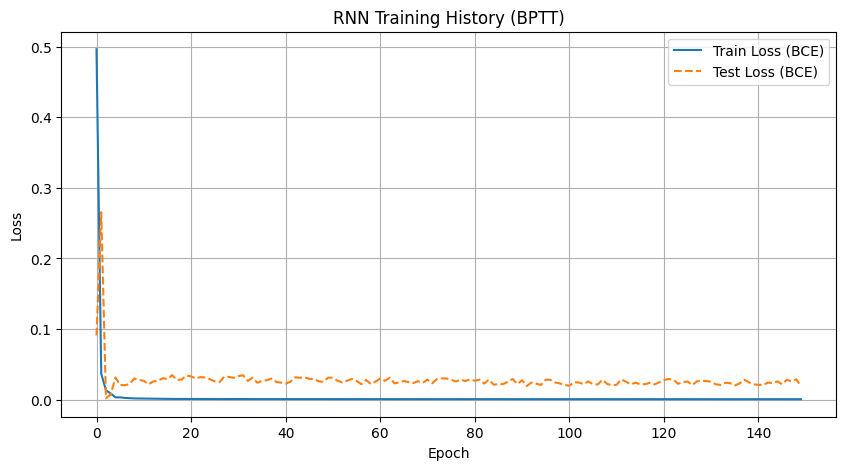

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Setup Dataset (Assuming 100 sequences) ---
num_samples = 100
X_data = np.random.randn(num_samples, 3, 3) 
# y=1 if sum of elements is positive, else 0
y_data = (np.sum(X_data, axis=(1, 2)) > 0).astype(float)

# Split into Train/Test (80/20)
X_train, X_test = X_data[:80], X_data[80:]
y_train, y_test = y_data[:80], y_data[80:]

# --- 2. Training and Test Loops ---
epochs = 150
train_history = []
test_history = []

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    epoch_train_losses = []
    # Shuffle for better learning
    indices = np.random.permutation(len(X_train))
    
    for i in indices:
        X_seq = X_train[i]
        y_true = y_train[i]
        
        o = np.zeros((4, 3)) 
        for t in range(1, 4):
            o[t] = X_seq[t-1] @ Wi + o[t-1] @ Wh
        
        y_hat = sigmoid(o[3] @ Wo)
        
        # Calculate BCE Loss
        loss = -(y_true * np.log(y_hat + 1e-9) + (1 - y_true) * np.log(1 - y_hat + 1e-9))
        epoch_train_losses.append(loss)

        error = (y_hat - y_true).reshape(1, 1)
        dWo = o[3:4].T @ error 
        d_h3 = error @ Wo.T 
        d_h2 = d_h3 @ Wh.T
        d_h1 = d_h2 @ Wh.T
        dWi = X_seq[2:3].T @ d_h3 + X_seq[1:2].T @ d_h2 + X_seq[0:1].T @ d_h1
        dWh = o[2:3].T @ d_h3 + o[1:2].T @ d_h2 + o[0:1].T @ d_h1

        # Update Weights
        Wo -= learning_rate * dWo
        Wh -= learning_rate * dWh
        Wi -= learning_rate * dWi
    
    train_history.append(np.mean(epoch_train_losses))

    # --- TEST PHASE (No Updates) ---
    epoch_test_losses = []
    for i in range(len(X_test)):
        X_val = X_test[i]
        y_val = y_test[i]
        
        # Forward pass only
        o_val = np.zeros((4, 3))
        for t in range(1, 4):
            o_val[t] = X_val[t-1] @ Wi + o_val[t-1] @ Wh
        y_hat_val = sigmoid(o_val[3] @ Wo)
        
        v_loss = -(y_val * np.log(y_hat_val + 1e-9) + (1 - y_val) * np.log(1 - y_hat_val + 1e-9))
        epoch_test_losses.append(v_loss)
        
    test_history.append(np.mean(epoch_test_losses))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss {train_history[-1]:.4f} | Test Loss {test_history[-1]:.4f}")

# --- 3. Visualization ---


plt.figure(figsize=(10, 5))
plt.plot(train_history, label='Train Loss ')
plt.plot(test_history, label='Test Loss ', linestyle='--')
plt.title('RNN Training History (BPTT)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import torch

# Returns True if a GPU is available
print(f"Is CUDA available? {torch.cuda.is_available()}")

# Returns the name of your GPU (e.g., 'NVIDIA GeForce RTX 4090')
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(torch.__version__)

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
2.9.1+cu130
